# Set Parameters

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1M PARAMS

d_model = 160
num_heads = 8
num_layers = 4
dim_feedforward = 320
dropout = 0.1
batch_size = 32
learning_rate = 1e-4

In [ ]:
# # 400K PARAMS

# d_model = 128
# num_heads = 8
# num_layers = 4
# dim_feedforward = 256
# dropout = 0.1
# batch_size = 32
# learning_rate = 1e-4
# # max_epochs = 3000
# save_every = 100

In [ ]:
# 100K PARAMS

# d_model = 64
# num_heads = 4
# num_layers = 3
# dim_feedforward = 128
# dropout = 0.1
# batch_size = 32
# learning_rate = 1e-5
# max_epochs = 1000
# save_every = 100

Imports

In [ ]:
import torch
import torch.nn as nn
import math
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import os

# Dataset Class

In [ ]:
# base_path = '/content/drive/MyDrive/Study Materials/MS Thesis/Code/10k data/' # For rohit21 account
base_path = '/content/drive/MyDrive/Projects/CosmoFormer Temp/1M HeteroLoss/' # For rohitptnk account

In [ ]:
class ClDataset(Dataset):
    def __init__(self, noisy_path, true_path, eps=1e-10):
        noisy = np.load(noisy_path)  # shape: (num_samples, seq_len)
        true  = np.load(true_path)

        assert noisy.shape == true.shape, "Input and target shapes must match!"

        self.eps = eps

        mean = np.mean(noisy)
        std = np.std(noisy)
        self.mean_np = mean
        self.std_np = std
        self.mean = torch.tensor(mean, dtype=torch.float32)
        self.std = torch.tensor(std, dtype=torch.float32)

        # Standardize data (done in numpy first)
        self.noisy = torch.tensor((noisy - mean) / std, dtype=torch.float32)
        self.true  = torch.tensor((true - mean) / std, dtype=torch.float32)
        torch.save({'mean': self.mean, 'std': self.std}, f"{base_path}scaler.pth")


    def __len__(self):
        return self.noisy.shape[0]

    def __getitem__(self, idx):
        return self.noisy[idx], self.true[idx]

    def inverse_transform(self, arr):
        if not torch.is_tensor(arr):
            arr = torch.tensor(arr, dtype=torch.float32)
        return arr * self.std.to(arr.device) + self.mean.to(arr.device)


# Train Test Split

In [ ]:
dataset = ClDataset(f"{base_path}noisy_cls_50k.npy", f"{base_path}true_cls_50k.npy")

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Positional Encoding

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return x

In [ ]:
class LearnablePositionalEncoding(nn.Module):
    def __init__(self, d_model, seq_len):
        super().__init__()
        # Learnable positional embeddings
        self.pos_embedding = nn.Embedding(seq_len, d_model)
        self.register_buffer('positions', torch.arange(seq_len).unsqueeze(0))  # shape (1, seq_len)

    def forward(self, x):
        # x shape: (batch, seq_len, d_model)
        positions = self.positions[:, :x.size(1)].to(x.device)
        pos_emb = self.pos_embedding(positions)  # (1, seq_len, d_model)
        return x + pos_emb


# Transformer Block

In [ ]:
class Transformer1DAutoencoder(nn.Module):
    def __init__(self, seq_len, d_model, nhead, num_layers, dim_feedforward, dropout):
        super().__init__()
        self.seq_len = seq_len
        self.d_model = d_model

        # input embedding (1D scalar → d_model)
        self.input_proj = nn.Linear(1, d_model)

        # positional encoding
        self.pos_encoder = LearnablePositionalEncoding(d_model, seq_len)
        # self.pos_encoder = PositionalEncoding(d_model, max_len=seq_len)

        # encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True  # batch_first=True makes input shape (batch, seq_len, d_model)
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # output projection (d_model → scalar)
        # self.output_proj = nn.Linear(d_model, 1)

        # for heteroscedastic loss
        self.output_proj = nn.Linear(d_model, 2)


    def forward(self, x):
        # x: (batch, seq_len)
        x = x.unsqueeze(-1)  # (batch, seq_len, 1)
        x = self.input_proj(x)  # (batch, seq_len, d_model)
        x = self.pos_encoder(x)  # add positional encoding
        x = self.encoder(x)      # Transformer Encoder
        x = self.output_proj(x)  # (batch, seq_len, 1)
        return x.squeeze(-1)     # (batch, seq_len)

Heteroscedastic Loss

In [ ]:
class HeteroscedasticLoss(nn.Module):
    def forward(self, pred, target):
        mean = pred[..., 0]
        log_var = pred[..., 1]
        precision = torch.exp(-log_var)

        loss = torch.mean(precision * (target - mean)**2 + log_var)
        return loss

# Initialize model, loss and optimizer

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Transformer1DAutoencoder(
    seq_len=dataset.noisy.shape[1],  # sequence length = lmax
    d_model=d_model,
    nhead=num_heads,
    num_layers=num_layers,
    dim_feedforward=dim_feedforward,
    dropout=dropout
).to(device)

# criterion = nn.MSELoss()
criterion = HeteroscedasticLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

## Checkpoint if exists

In [ ]:
checkpoint_dir = f"{base_path}checkpoints" # Save checkpoints to Google Drive
os.makedirs(checkpoint_dir, exist_ok=True)
start_epoch = 0
checkpoint_path = os.path.join(checkpoint_dir, "best_model.pth")

In [ ]:
# Resume from checkpoint if exists
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    # start_epoch = 0
    print(f"Resuming training from epoch {start_epoch} from {checkpoint_path}")
else:
  print("Training from scratch")

Resuming training from epoch 22 from /content/drive/MyDrive/Projects/CosmoFormer Temp/1M HeteroLoss/checkpoints/best_model.pth


# Training Code

In [ ]:
loss_list_path = f'{base_path}loss_list.npy'
if os.path.exists(loss_list_path):
  loss_list = np.load(loss_list_path).tolist()
  print(f"loaded losses from {loss_list_path}")
else:
  loss_list = []
print(len(loss_list))

loaded losses from /content/drive/MyDrive/Projects/CosmoFormer Temp/1M HeteroLoss/loss_list.npy
72


In [ ]:
# for new parameters
loss_list = []

In [ ]:
# --- Config ---
num_epochs = 1000
patience = 50  # early stopping patience
best_val_loss = np.inf
epochs_no_improve = 0
save_path = checkpoint_path


scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,     # multiply LR by this factor
    patience=10    # number of epochs with no improvement before reducing
)


for epoch in range(start_epoch, num_epochs):
    model.train()
    train_loss = 0
    for noisy, true in train_loader:
        noisy, true = noisy.to(device), true.to(device)
        optimizer.zero_grad()
        output = model(noisy)
        loss = criterion(output, true)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for noisy, true in test_loader:
            noisy, true = noisy.to(device), true.to(device)
            output = model(noisy)

            val_loss += criterion(output, true).item()

    val_loss /= len(test_loader)
    loss_list.append(val_loss)

    scheduler.step(val_loss)  # ← important line

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss
            }, save_path)
        print(f"Epoch {epoch+1}, Train Loss: {loss.item():.6f}, Val Loss: {val_loss:.6f}")
        print(f"✅ Saved new best model (val_loss={val_loss:.6f})")
    else:
        epochs_no_improve += 1

    # Early stopping
    if epochs_no_improve >= patience:
        print(f"⏹ Early stopping triggered at epoch {epoch+1}")
        break

np.save(f"{base_path}loss_list.npy", np.array(loss_list))

    # # Save checkpoint
    # if (epoch + 1) % save_every == 0:
    #     checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_epoch_{epoch+1}.pth")
    #     torch.save({
    #         'epoch': epoch,
    #         'model_state_dict': model.state_dict(),
    #         'optimizer_state_dict': optimizer.state_dict(),
    #         'train_loss': avg_loss
    #     }, checkpoint_path)
    #     loss_list.append(avg_loss)
    #     print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_loss:.6f}")
    #     print(f"Checkpoint saved at epoch {epoch+1}")



KeyboardInterrupt: 

# Evaluation

In [ ]:
model.eval()
test_loss = 0
with torch.no_grad():
    for noisy, true in test_loader:
        noisy, true = noisy.to(device), true.to(device) #change dtype
        output = model(noisy)
        # output_original = dataset.inverse_transform(output)
        # true_original = dataset.inverse_transform(true)
        loss = criterion(output, true)
        test_loss += loss.item()

print(f"Test MSE: {test_loss/len(test_loader):.6f}")

Test MSE: -1.775850


# Visualization

In [ ]:
pic_path = f'{base_path}Plots/'
os.makedirs(pic_path, exist_ok=True)

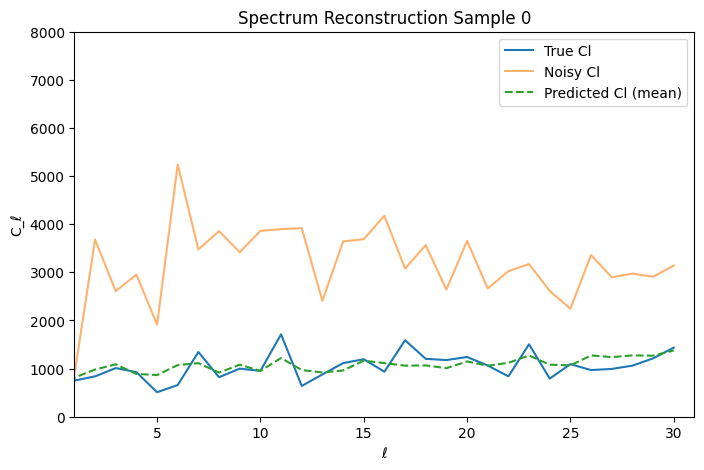

In [ ]:
noisy_batch, true_batch = next(iter(test_loader))
noisy_batch = noisy_batch.to(device)
true_batch  = true_batch.to(device)

pred = model(noisy_batch)
pred_mean = pred[..., 0]

true_orig  = dataset.inverse_transform(true_batch)
noisy_orig = dataset.inverse_transform(noisy_batch)
pred_mean_orig = dataset.inverse_transform(pred_mean)

true_np  = true_orig.cpu().detach().numpy()
noisy_np = noisy_orig.cpu().detach().numpy()
mean_np  = pred_mean_orig.cpu().detach().numpy()

# Plot
idx = 0
plt.figure(figsize=(8,5))
plt.plot(true_np[idx], label="True Cl")
plt.plot(noisy_np[idx], label="Noisy Cl", alpha=0.6)
plt.plot(mean_np[idx], label="Predicted Cl (mean)", linestyle="--")
plt.legend()
plt.xlim([1, len(true_np[idx])])
plt.ylim(0, 8000)
plt.xlabel("ℓ")
plt.ylabel("C_ℓ")
plt.title(f"Spectrum Reconstruction Sample {idx}")
plt.savefig(f'{pic_path}sample{idx}.png')
plt.show()

Added Gaussian Noise

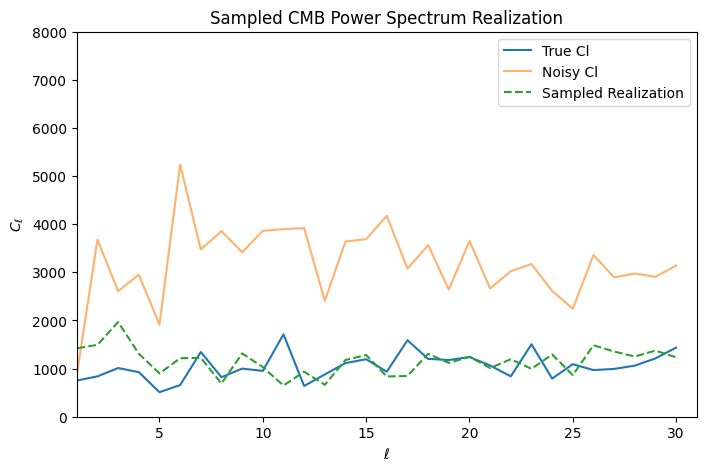

In [ ]:
output = model(noisy_batch)
pred_mean = output[..., 0]
pred_logvar = output[..., 1]

pred_var_norm = torch.exp(pred_logvar)
pred_var_orig = pred_var_norm * (dataset.std.to(device)**2)
pred_mean_orig = dataset.inverse_transform(pred_mean)

eps = torch.randn_like(pred_mean_orig)
sampled = pred_mean_orig + torch.sqrt(pred_var_orig)*eps

sample_np = sampled.cpu().detach().numpy()


# Plot
plt.figure(figsize=(8,5))
plt.plot(true[idx], label="True Cl")
plt.plot(noisy[idx], label="Noisy Cl", alpha=0.6)
plt.plot(sample_np[idx], label="Sampled Realization", linestyle="--")
plt.legend()
plt.xlabel(r"$\ell$")
plt.ylabel(r"$C_\ell$")
plt.ylim(0, 8000)
plt.xlim([1, len(true_np[idx])])
plt.title("Sampled CMB Power Spectrum Realization")
plt.show()


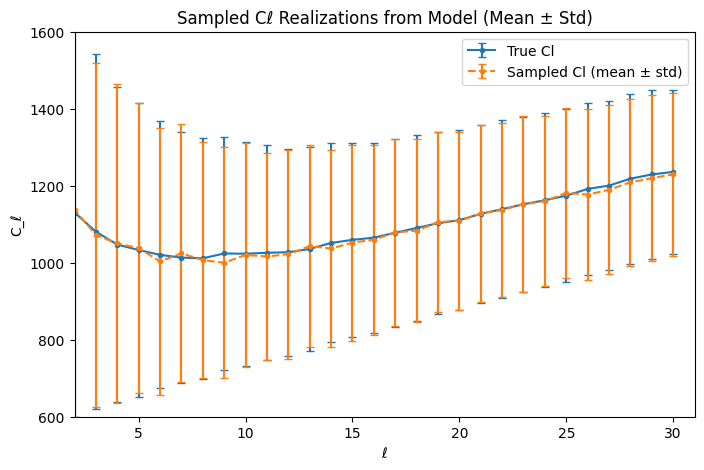

In [ ]:
model.eval()
true_values = []
pred_mean_values = []
pred_sample_values = []

with torch.no_grad():
    for noisy, true in test_loader:
        noisy, true = noisy.to(device), true.to(device)

        output = model(noisy)   # (batch, seq_len, 2)
        pred_mean = output[..., 0]
        pred_logvar = output[..., 1]

        # Variance in normalized space
        pred_var_norm = torch.exp(pred_logvar)

        # Convert mean and variance to original scale
        pred_mean_orig = dataset.inverse_transform(pred_mean)
        true_orig = dataset.inverse_transform(true)
        pred_var_orig = pred_var_norm * (dataset.std.to(device)**2)

        # Sample Gaussian noise for each ℓ for each sample
        eps = torch.randn_like(pred_mean_orig)
        pred_sample = pred_mean_orig + torch.sqrt(pred_var_orig) * eps

        # Move to CPU numpy
        true_values.append(true_orig.cpu().numpy())
        pred_mean_values.append(pred_mean_orig.cpu().numpy())
        pred_sample_values.append(pred_sample.cpu().numpy())

true_all = np.concatenate(true_values, axis=0)
pred_mean_all = np.concatenate(pred_mean_values, axis=0)
pred_sample_all = np.concatenate(pred_sample_values, axis=0)

true_mean = np.mean(true_all, axis=0)
true_std  = np.std(true_all, axis=0)

sample_mean = np.mean(pred_sample_all, axis=0)
sample_std  = np.std(pred_sample_all, axis=0)

plt.figure(figsize=(8,5))
ell = np.arange(len(true_mean))

# True curves (reference)
plt.errorbar(
    ell, true_mean, yerr=true_std,
    fmt='-o', markersize=3, capsize=3,
    label="True Cl"
)

# Sampled realizations from model
plt.errorbar(
    ell, sample_mean, yerr=sample_std,
    fmt='--o', markersize=3, capsize=3,
    label="Sampled Cl (mean ± std)"
)

plt.legend()
plt.xlim([2, len(true_mean)])
plt.ylim(600, 1600)
plt.xlabel("ℓ")
plt.ylabel("C_ℓ")
plt.title("Sampled Cℓ Realizations from Model (Mean ± Std)")
plt.savefig(f"{pic_path}sampled_realizations_error.png")
plt.show()


Loss Plots

[-1.7337776293008091, -1.74950139210247, -1.7587568085795393, -1.7287177525389308, -1.7573869053167277, -1.7608515146060493, -1.7607712673303038, -1.7633263912444679, -1.761177848322323, -1.76615550190496, -1.76610259545116, -1.7657215534307706, -1.7644631017130403, -1.762966742149938, -1.7624819133990108, -1.764305050761555, -1.7627426557266674, -1.759888445226529, -1.7610677214095387, -1.7652333574934889, -1.7642855827039041, -1.7688672325481622, -1.7655007922992159, -1.7648769818936674, -1.7559840839130048, -1.7675016874703355, -1.767738750186591, -1.765229899281511, -1.7640385623937977, -1.7618508628382088, -1.7661749707243313, -1.7561815699068501, -1.765227927567479, -1.7643966419628252, -1.7687886164972957, -1.7646401366486717, -1.7659666713434286, -1.7628128239141105, -1.7672841427044366, -1.7664472020853061, -1.7641291332701905, -1.7632060999306627, -1.767482003084006, -1.7652898684096412, -1.7654936820173417, -1.7650815956889632, -1.7661259913216003, -1.7652948786275455, -1.76

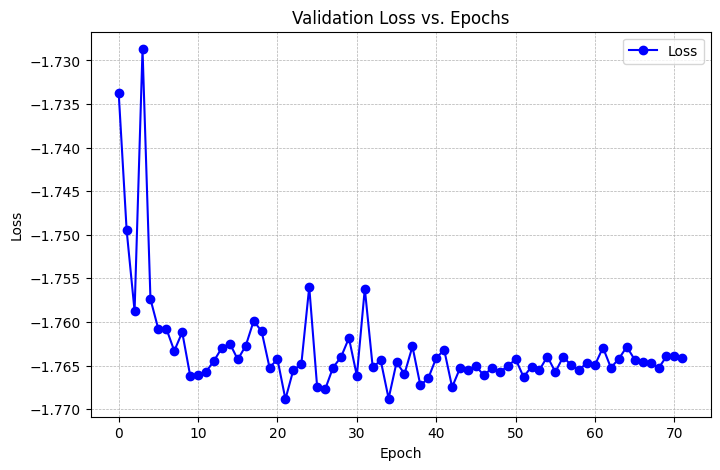

In [ ]:
print(loss_list)

plt.figure(figsize=(8,5))
plt.plot(loss_list,
         marker='o', linestyle='-',
         color='blue', label='Loss')

# plt.yscale('log')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss vs. Epochs')

plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.legend()
plt.savefig(f'{pic_path}loss_plot.png')
plt.show()

In [ ]:
model.eval()

all_pred_logvar = []
all_pred_mean = []
all_true = []

with torch.no_grad():
    for noisy, true in test_loader:
        noisy, true = noisy.to(device), true.to(device)

        output = model(noisy)   # shape: (batch, seq_len, 2)

        pred_mean = output[..., 0]       # (batch, seq_len)
        pred_logvar = output[..., 1]     # (batch, seq_len)

        # Convert log variance to variance (still in normalized space)
        pred_var = torch.exp(pred_logvar)
        # pred_var = pred_logvar
        # Inverse-transform mean and true to original scale
        true_orig = dataset.inverse_transform(true)
        pred_mean_orig = dataset.inverse_transform(pred_mean)

        # Store arrays
        all_pred_mean.append(pred_mean_orig.cpu().numpy())
        all_pred_logvar.append(pred_var.cpu().numpy())    # variance
        all_true.append(true_orig.cpu().numpy())


# Stack all batches into (N_test, seq_len)
pred_mean_all = np.concatenate(all_pred_mean, axis=0)
pred_var_all  = np.concatenate(all_pred_logvar, axis=0)
true_all      = np.concatenate(all_true, axis=0)

# Compute true residuals
residuals = true_all - pred_mean_all   # (N_test, seq_len)

# True residual variance at each ℓ
true_residual_var = np.mean(residuals**2, axis=0)

# Predicted variance (average across test set)
predicted_var = np.mean(pred_var_all, axis=0)


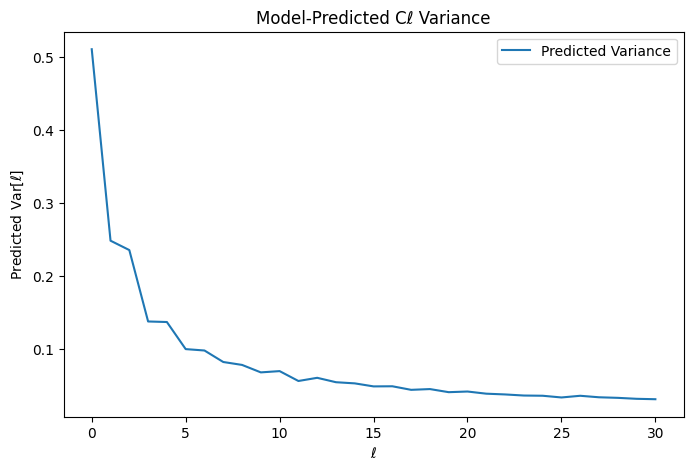

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(predicted_var, label="Predicted Variance")
plt.xlabel("ℓ")
plt.ylabel("Predicted Var[$\\ell$]")
plt.title("Model-Predicted Cℓ Variance")
plt.legend()
plt.savefig(f"{pic_path}predicted_variance.png")
plt.show()


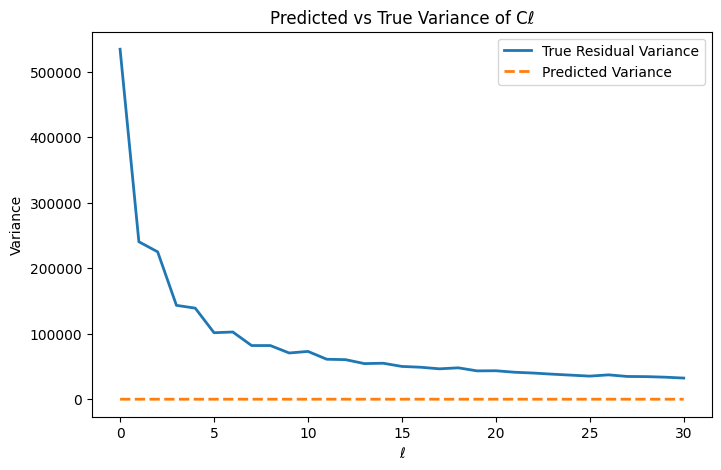

In [ ]:
plt.figure(figsize=(8,5))
ell = np.arange(len(predicted_var))

plt.plot(ell, true_residual_var, label="True Residual Variance", linewidth=2)
plt.plot(ell, predicted_var, label="Predicted Variance", linestyle="--", linewidth=2)

plt.xlabel("ℓ")
plt.ylabel("Variance")
plt.title("Predicted vs True Variance of Cℓ")
plt.legend()
plt.savefig(f"{pic_path}variance_comparison.png")
plt.show()


Inidividual var

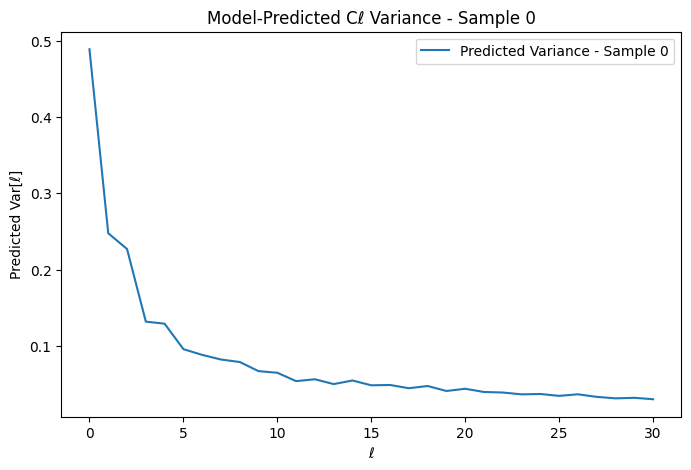

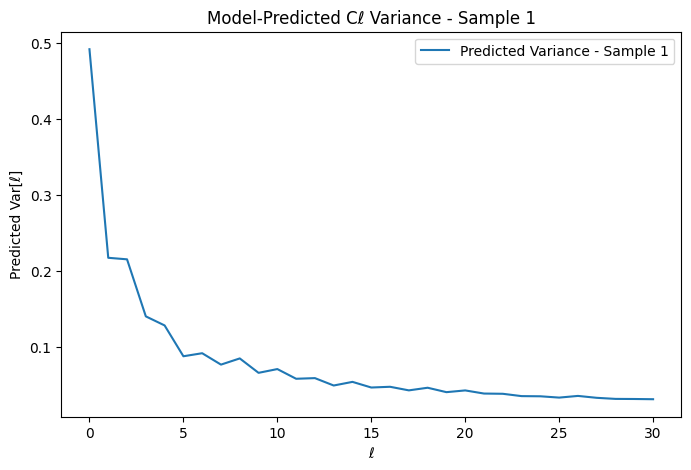

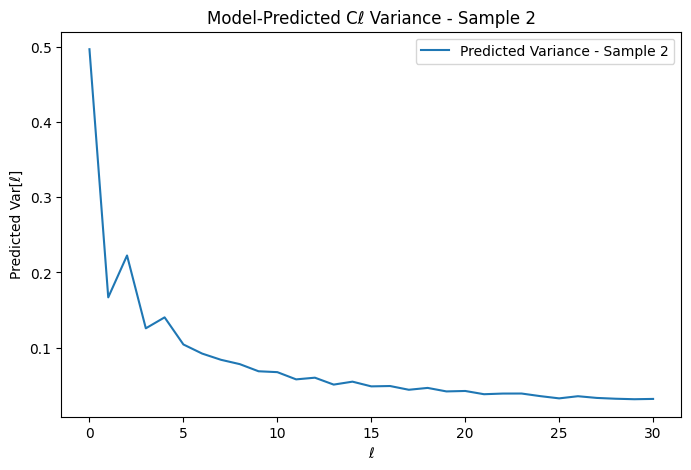

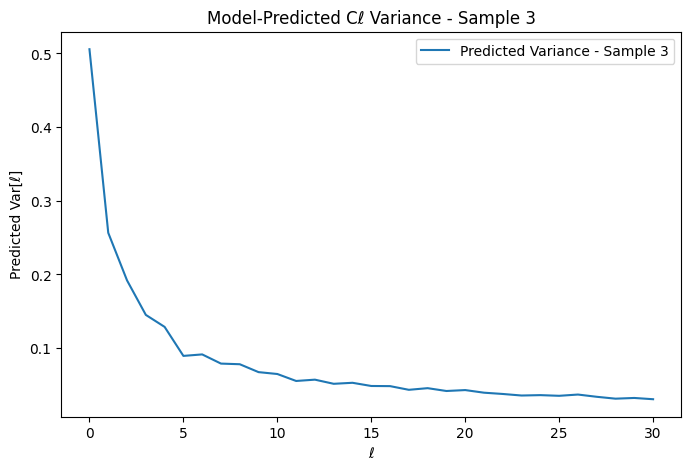

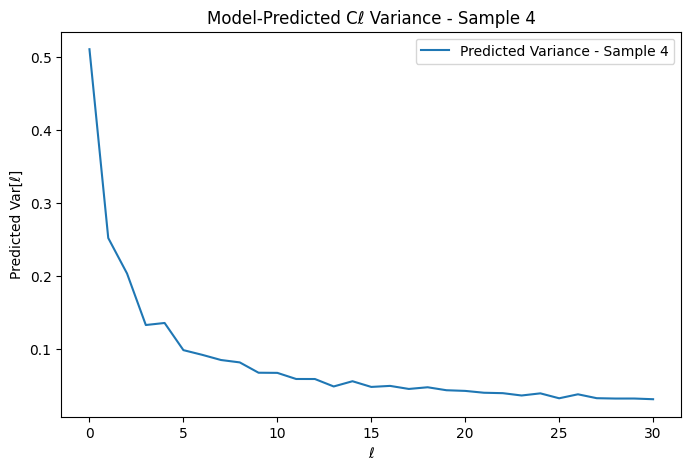

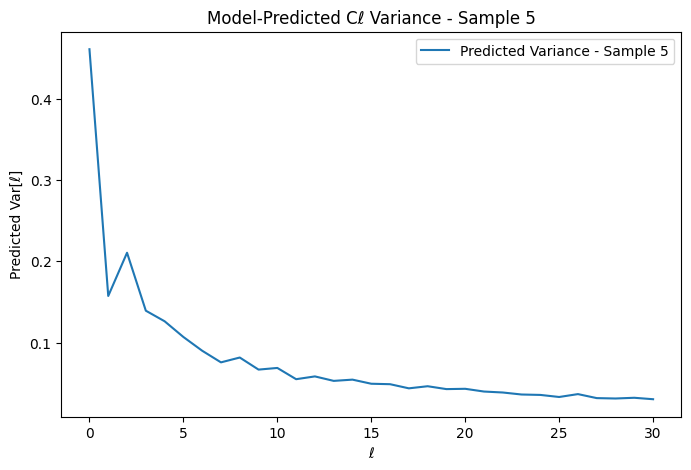

In [ ]:
model.eval()

all_pred_logvar = []
all_pred_mean = []
all_true = []

with torch.no_grad():

    for i, (noisy, true) in enumerate(test_loader):
        if i >= 1:
            break

        noisy, true = noisy.to(device), true.to(device)

        output = model(noisy)   # shape: (batch, seq_len, 2)

        pred_mean = output[..., 0]       # (batch, seq_len)
        pred_logvar = output[..., 1]     # (batch, seq_len)

        # Convert log variance to variance (still in normalized space)
        pred_var = torch.exp(pred_logvar)

        # Move to CPU and convert to numpy for plotting
        for ind, j in enumerate(range(pred_var.shape[0])): # Iterate through each sample in the batch
            if ind > 5:
              break
            plt.figure(figsize=(8,5))
            plt.plot(pred_var[j].cpu().numpy(), label=f"Predicted Variance - Sample {i*batch_size + j}")
            plt.xlabel("ℓ")
            plt.ylabel("Predicted Var[ℓ]")
            plt.title(f"Model-Predicted Cℓ Variance - Sample {i*batch_size + j}")
            plt.legend()
            plt.show()
